<a href="https://colab.research.google.com/github/Abhinav9895/Generative-AI-Internship/blob/main/Day4/ImagePreprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

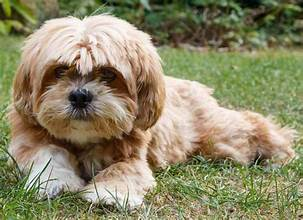

In [13]:
from PIL import Image,ImageEnhance,ImageOps
image=Image.open("/content/OIP (3).jpg")
image_resized=image.resize((400,224))
image



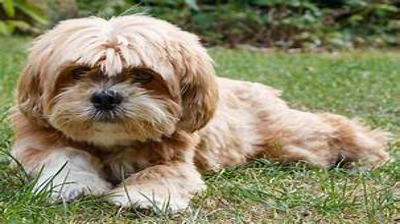

In [6]:
image_resized

In [8]:
import numpy as np
image_array=np.array(image)/255.0
image_array

array([[[0.60392157, 0.64705882, 0.3372549 ],
        [0.60392157, 0.64705882, 0.3372549 ],
        [0.56470588, 0.61568627, 0.29411765],
        ...,
        [0.27058824, 0.27843137, 0.23529412],
        [0.23137255, 0.23921569, 0.19607843],
        [0.20392157, 0.21568627, 0.18039216]],

       [[0.52156863, 0.56470588, 0.26666667],
        [0.5372549 , 0.58039216, 0.2745098 ],
        [0.5254902 , 0.57647059, 0.2627451 ],
        ...,
        [0.20392157, 0.21176471, 0.16078431],
        [0.18431373, 0.19607843, 0.15294118],
        [0.18823529, 0.2       , 0.15686275]],

       [[0.35686275, 0.39607843, 0.1254902 ],
        [0.40784314, 0.44705882, 0.16862745],
        [0.45882353, 0.49803922, 0.21176471],
        ...,
        [0.1372549 , 0.14509804, 0.09019608],
        [0.10980392, 0.1254902 , 0.07058824],
        [0.10588235, 0.12156863, 0.06666667]],

       ...,

       [[0.38431373, 0.40392157, 0.19215686],
        [0.37647059, 0.40784314, 0.17647059],
        [0.4627451 , 0

array([[140, 140, 131, ...,  67,  57,  52],
       [120, 123, 122, ...,  50,  46,  47],
       [ 79,  92, 104, ...,  33,  27,  26],
       ...,
       [ 86,  85, 107, ...,  96,  82,  89],
       [100,  98, 117, ..., 135, 136, 136],
       [119, 109, 120, ..., 111, 193, 201]], dtype=uint8)
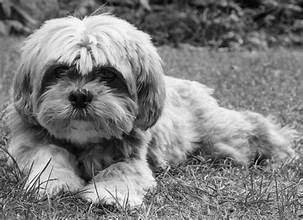

In [12]:
from cv2 import cvtColor,COLOR_BGR2GRAY
image_np=np.array(image)
grayscale_image=cvtColor(image_np,COLOR_BGR2GRAY)
grayscale_image

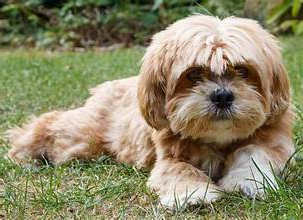

In [15]:
import os
flipped=ImageOps.mirror(image)
flipped

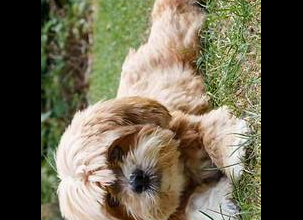

In [17]:
rotated=image.rotate(90)
rotated

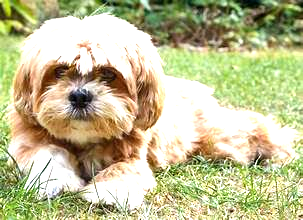

In [18]:
enhancer=ImageEnhance.Brightness(image)
brighter=enhancer.enhance(1.5)
brighter

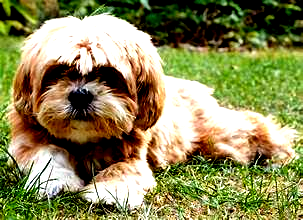

In [20]:
contrast=ImageEnhance.Contrast(image).enhance(2.0)
contrast

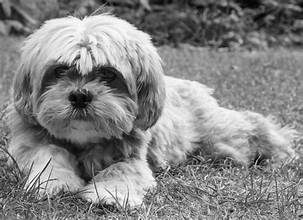

In [21]:
grayscale=ImageOps.grayscale(image)
grayscale

In [23]:
from PIL import Image, ImageEnhance, ImageOps
#PIL: Python Imaging Library (via Pillow), used for image processing.
#Image: Handles image loading, saving, and manipulation.
#ImageEnhance: Provides tools for enhancing image properties like brightness and contrast.
#ImageOps: Contains image processing utilities, such as flipping and grayscaling.
#os: A module to handle file system operations like creating directories and file paths.

import os

# Load the uploaded image
image_path = "/content/OIP (3).jpg"  # Replace with your image file path
image = Image.open(image_path)

# Create a directory for augmented images
augmented_dir = "augmented_images"
#Creates the directory augmented_images
os.makedirs(augmented_dir, exist_ok=True)
 #Ensures no error is raised if the directory already exists.

# Augmentation functions
def augment_image(image, output_dir):
    # 1. Horizontal Flip
    # Flips the image horizontally (mirroring).
    flipped = ImageOps.mirror(image)
    #Saves the flipped image as flipped.jpeg in the output_dir
    flipped.save(os.path.join(output_dir, "flipped.jpeg"))

    # 2. Rotate
    rotated = image.rotate(30)
    #Rotates the image by 30 degrees (counterclockwise by default)
    rotated.save(os.path.join(output_dir, "rotated.jpeg"))

    # 3. Brightness Adjustment
    enhancer = ImageEnhance.Brightness(image)
    #Adjusts brightness by a factor of 1.5 (1.0 = original brightness).
    brighter = enhancer.enhance(1.5)
    brighter.save(os.path.join(output_dir, "brighter.jpeg"))

    # 4. Contrast Adjustment
    contrast = ImageEnhance.Contrast(image).enhance(2.0)
    #Doubles the image's contrast (2.0 = twice the original contrast).

    contrast.save(os.path.join(output_dir, "contrast.jpeg"))

    # 5. Grayscale
    grayscale = ImageOps.grayscale(image)
    grayscale.save(os.path.join(output_dir, "grayscale.jpeg"))

# Apply augmentations
augment_image(image, augmented_dir)
#Calls the augment_image function to apply all augmentations on the loaded image and save the results in the augmented_images directory.

# List the augmented files
print("Augmented images saved in:", augmented_dir)
print("Generated files:", os.listdir(augmented_dir))

Augmented images saved in: augmented_images
Generated files: ['rotated.jpeg', 'brighter.jpeg', 'flipped.jpeg', 'grayscale.jpeg', 'contrast.jpeg']


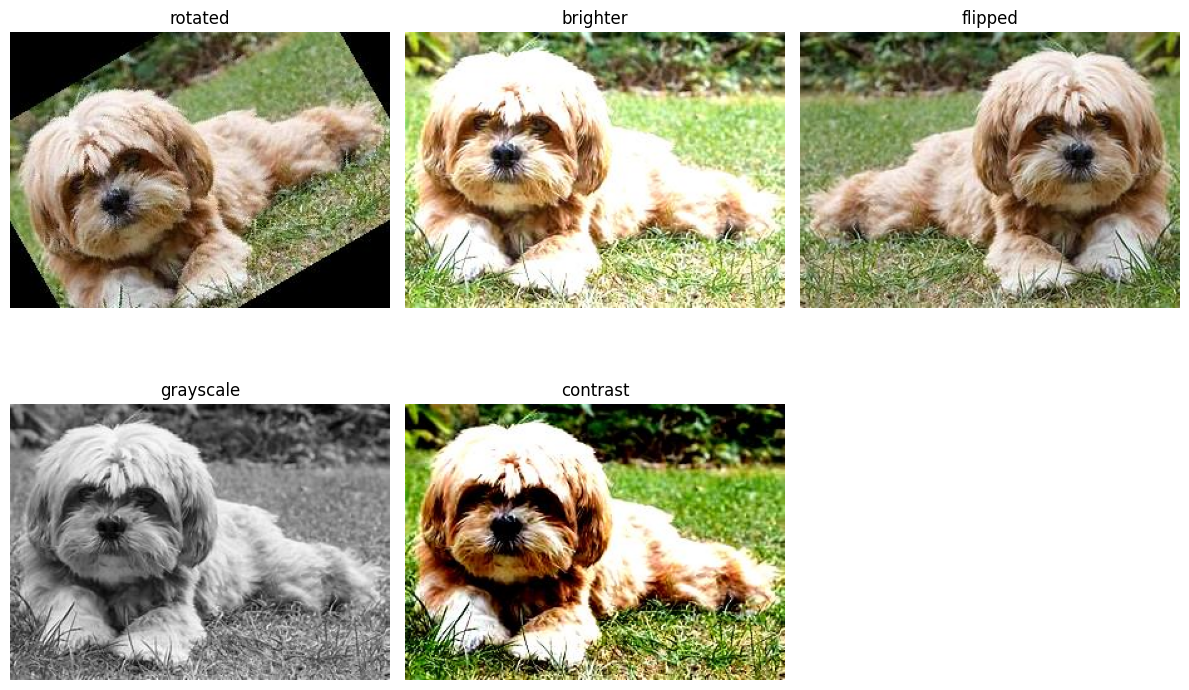

In [25]:
import matplotlib.pyplot as plt

augmented_dir = "augmented_images"
augmented_images=os.listdir(augmented_dir)

plt.figure(figsize=(12,8))

for i,img_file in enumerate(augmented_images):
  img_path=os.path.join(augmented_dir,img_file)
  img=Image.open(img_path)
  plt.subplot(2,3,i+1)
  plt.imshow(img,cmap="gray" if img.mode=="L" else None)
  plt.title(img_file.split('.')[0])
  plt.axis("off")

plt.tight_layout()
plt.show()